# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace.

<img src=https://i.imgur.com/36pCx5Q.jpg>

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

### Upgrade plotly

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.3 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format #disply all floats as 2 sf after the dot

### Read the Data

In [ ]:
# Read the Data
df_data = pd.read_csv('nobel_prize_data.csv')
# First 5 Rows of the Dataframe
df_data.head(5)
# Last 5 Rows of the Dataframe
df_data.tail(5)

Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd.


# Data Exploration & Cleaning


In [ ]:
df_data.shape # Display the Number of Rows of Rows and Columns in the dataframe

(962, 16)

In [ ]:
df_data.info() # Concise Dataframe Summary for quick data exploration and identifying missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

In [ ]:
# The First Nobel Prize Award Year
first_nobel_prize = df_data.value_counts('year').sort_values().index[0]
# The Last Nobel Prize Award Year
last_nobel_prize = df_data.value_counts('year').sort_values(ascending=False).index[0]

### Check for Duplicates

In [ ]:
duplicate_values = df_data.duplicated().sum()

np.int64(0)

### Check for NaN Values

In [ ]:
nan_values = df_data.isna().sum()

### Type Conversions

#### Convert Year and Birth Date to Datetime

In [ ]:
df_data.birth_date = pd.to_datetime(df_data.birth_date)

#### Add a Column with the Prize Share as a Percentage

In [ ]:
separated_values = df_data.prize_share.str.split('/',expand=True)
numerator = pd.to_numeric(separated_values[0])
denominator = pd.to_numeric(separated_values[1])
df_data['share_pct'] = numerator / denominator
df_data[:2]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD,1.00
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA,1.00


# Plotly Donut Chart: Percentage of Male vs. Female Laureates

Create a [donut chart using plotly](https://plotly.com/python/pie-charts/) which shows how many prizes went to men compared to how many prizes went to women. Calculate the percentage of all the prizes that went to women.

In [ ]:
males = df_data[df_data.sex=='Male'].shape[0]
females = df_data[df_data.sex=='Female'].shape[0]

In [ ]:
data = {'Category':['Male', 'Female'], 'Values':[males, females]}
fig = px.pie(data, values='Values', names='Category', hole=0.4)
fig.show()

# Who were the first 3 Women to Win the Nobel Prize?

List the names of the first 3 female Nobel laureates


In [ ]:
print(df_data[df_data.sex=='Female'].sort_values('year').head(3).full_name.values)

['Marie Curie, née Sklodowska'
 'Baroness Bertha Sophie Felicita von Suttner, née Countess Kinsky von Chinic und Tettau'
 'Selma Ottilia Lovisa Lagerlöf']


What did these first 3 female Nobel laureates win the Prize for?

In [ ]:
print(df_data[df_data.sex=='Female'].sort_values('year').head(3).prize.values)

['The Nobel Prize in Physics 1903' 'The Nobel Peace Prize 1905'
 'The Nobel Prize in Literature 1909']


What do you see in their birth_country? Were they part of an organisation?

In [ ]:
df_data[df_data.sex=='Female'].sort_values('year').head(3).birth_country

,birth_country
18,Russian Empire (Poland)
29,Austrian Empire (Czech Republic)
51,Sweden


In [ ]:
df_data[df_data.sex=='Female'].sort_values('year').head(3).organization_name

,organization_name
18,NaN
29,NaN
51,NaN


# Find the Repeat Winners

Did some people get a Nobel Prize more than once? If so, who were they?

In [ ]:
df_data[df_data.duplicated(subset=['full_name'], keep=False)]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,NaN,NaN,NaN,POL,0.25
62,1911,Chemistry,The Nobel Prize in Chemistry 1911,"""in recognition of her services to the advance...",1/1,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,Sorbonne University,Paris,France,POL,1.00
89,1917,Peace,The Nobel Peace Prize 1917,NaN,1/1,Organization,Comité international de la Croix Rouge (Intern...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00
215,1944,Peace,The Nobel Peace Prize 1944,NaN,1/1,Organization,Comité international de la Croix Rouge (Intern...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00
278,1954,Chemistry,The Nobel Prize in Chemistry 1954,"""for his research into the nature of the chemi...",1/1,Individual,Linus Carl Pauling,1901-02-28,"Portland, OR",United States of America,United States of America,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,USA,1.00
283,1954,Peace,The Nobel Peace Prize 1954,NaN,1/1,Organization,Office of the United Nations High Commissioner...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00
297,1956,Physics,The Nobel Prize in Physics 1956,"""for their researches on semiconductors and th...",1/3,Individual,John Bardeen,1908-05-23,"Madison, WI",United States of America,United States of America,Male,University of Illinois,"Urbana, IL",United States of America,USA,0.33
306,1958,Chemistry,The Nobel Prize in Chemistry 1958,"""for his work on the structure of proteins, es...",1/1,Individual,Frederick Sanger,1918-08-13,Rendcombe,United Kingdom,United Kingdom,Male,University of Cambridge,Cambridge,United Kingdom,GBR,1.00
340,1962,Peace,The Nobel Peace Prize 1962,NaN,1/1,Individual,Linus Carl Pauling,1901-02-28,"Portland, OR",United States of America,United States of America,Male,California Institute of Technology (Caltech),"Pasadena, CA",United States of America,USA,1.00
348,1963,Peace,The Nobel Peace Prize 1963,NaN,1/2,Organization,Comité international de la Croix Rouge (Intern...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50


# Number of Prizes per Category

**Challenge**:
* In how many categories are prizes awarded?
* Create a plotly bar chart with the number of prizes awarded by category.
* Use the color scale called `Aggrnyl` to colour the chart, but don't show a color axis.
* Which category has the most number of prizes awarded?
* Which category has the fewest number of prizes awarded?

In how many categories are prizes awarded?



In [ ]:
df_data.category.nunique()

6

Create a plotly bar chart with the number of prizes awarded by category.
Use the color scale called 'armyrose' to colour the chart, but don't show a color axis.
Which category has the most number of prizes awarded?
Which category has the fewest number of prizes awarded?


In [ ]:
prizes_per_category = df_data.category.value_counts()
v_bar = px.bar(
    x=prizes_per_category.index,
    y=prizes_per_category.values,
    color = prizes_per_category.values,
    color_continuous_scale='armyrose',
)
v_bar.update_layout(xaxis_title='Nobel Prize Category',
                    yaxis_title='Number of Prizes',
                    coloraxis_showscale=False)
v_bar.show()

When was the first prize in the field of Economics awarded? Who did the prize go to?

In [ ]:
df_data[df_data.category=='Economics'].sort_values('year')[:2]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,0.50
394,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,0.50


# Male and Female Winners by Category

Create a [plotly bar chart](https://plotly.com/python/bar-charts/) that shows the split between men and women by category.
* Hover over the bar chart. How many prizes went to women in Literature compared to Physics?

<img src=https://i.imgur.com/od8TfOp.png width=650>

In [ ]:
cat_men_women = df_data.groupby(['category', 'sex'], as_index=False).agg({'prize':pd.Series.count})
cat_men_women.sort_values('prize',ascending=False,inplace=True)
v_bar_split=px.bar(x=cat_men_women.category,
                   y=cat_men_women.prize,
                   color=cat_men_women.sex,
                   title='Number of Prizes Awarded per Category split by Men and Women')
v_bar_split.update_layout(xaxis_title='Nobel Prize Category', yaxis_title='Number of Prizes')
v_bar_split.show()

# Number of Prizes Awarded Over Time

Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually.
* Count the number of prizes awarded every year.
* Create a 5 year rolling average of the number of prizes (Hint: see previous lessons analysing Google Trends).
* Using Matplotlib superimpose the rolling average on a scatter plot.
* Show a tick mark on the x-axis for every 5 years from 1900 to 2020. (Hint: you'll need to use NumPy).

<img src=https://i.imgur.com/4jqYuWC.png width=650>

* Use the [named colours](https://matplotlib.org/3.1.0/gallery/color/named_colors.html) to draw the data points in `dogerblue` while the rolling average is coloured in `crimson`.

<img src=https://i.imgur.com/u3RlcJn.png width=350>

* Looking at the chart, did the first and second world wars have an impact on the number of prizes being given out?
* What could be the reason for the trend in the chart?


In [ ]:
prizes_per_year = df_data.groupby('year').count().prize

In [ ]:
moving_avg = prizes_per_year.rolling(window=5).mean()

In [ ]:
plt.scatter(x=prizes_per_year.index,
           y=prizes_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

plt.plot(prizes_per_year.index,
        moving_avg.values,
        c='crimson',
        linewidth=3,)
plt.title("Number of Prizes Per Year")

plt.show()

NameError: name 'plt' is not defined

# Are More Prizes Shared Than Before?

Investigate if more prizes are shared than before.

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.
* Plot the rolling average of the prize share on this chart.
* Invert the secondary y-axis to make the relationship even more clear.

In [ ]:
yearly_avg_share =df_data.groupby('year').agg({'share_pct':pd.Series.mean})
share_moving_average = yearly_avg_share.rolling(5).mean()

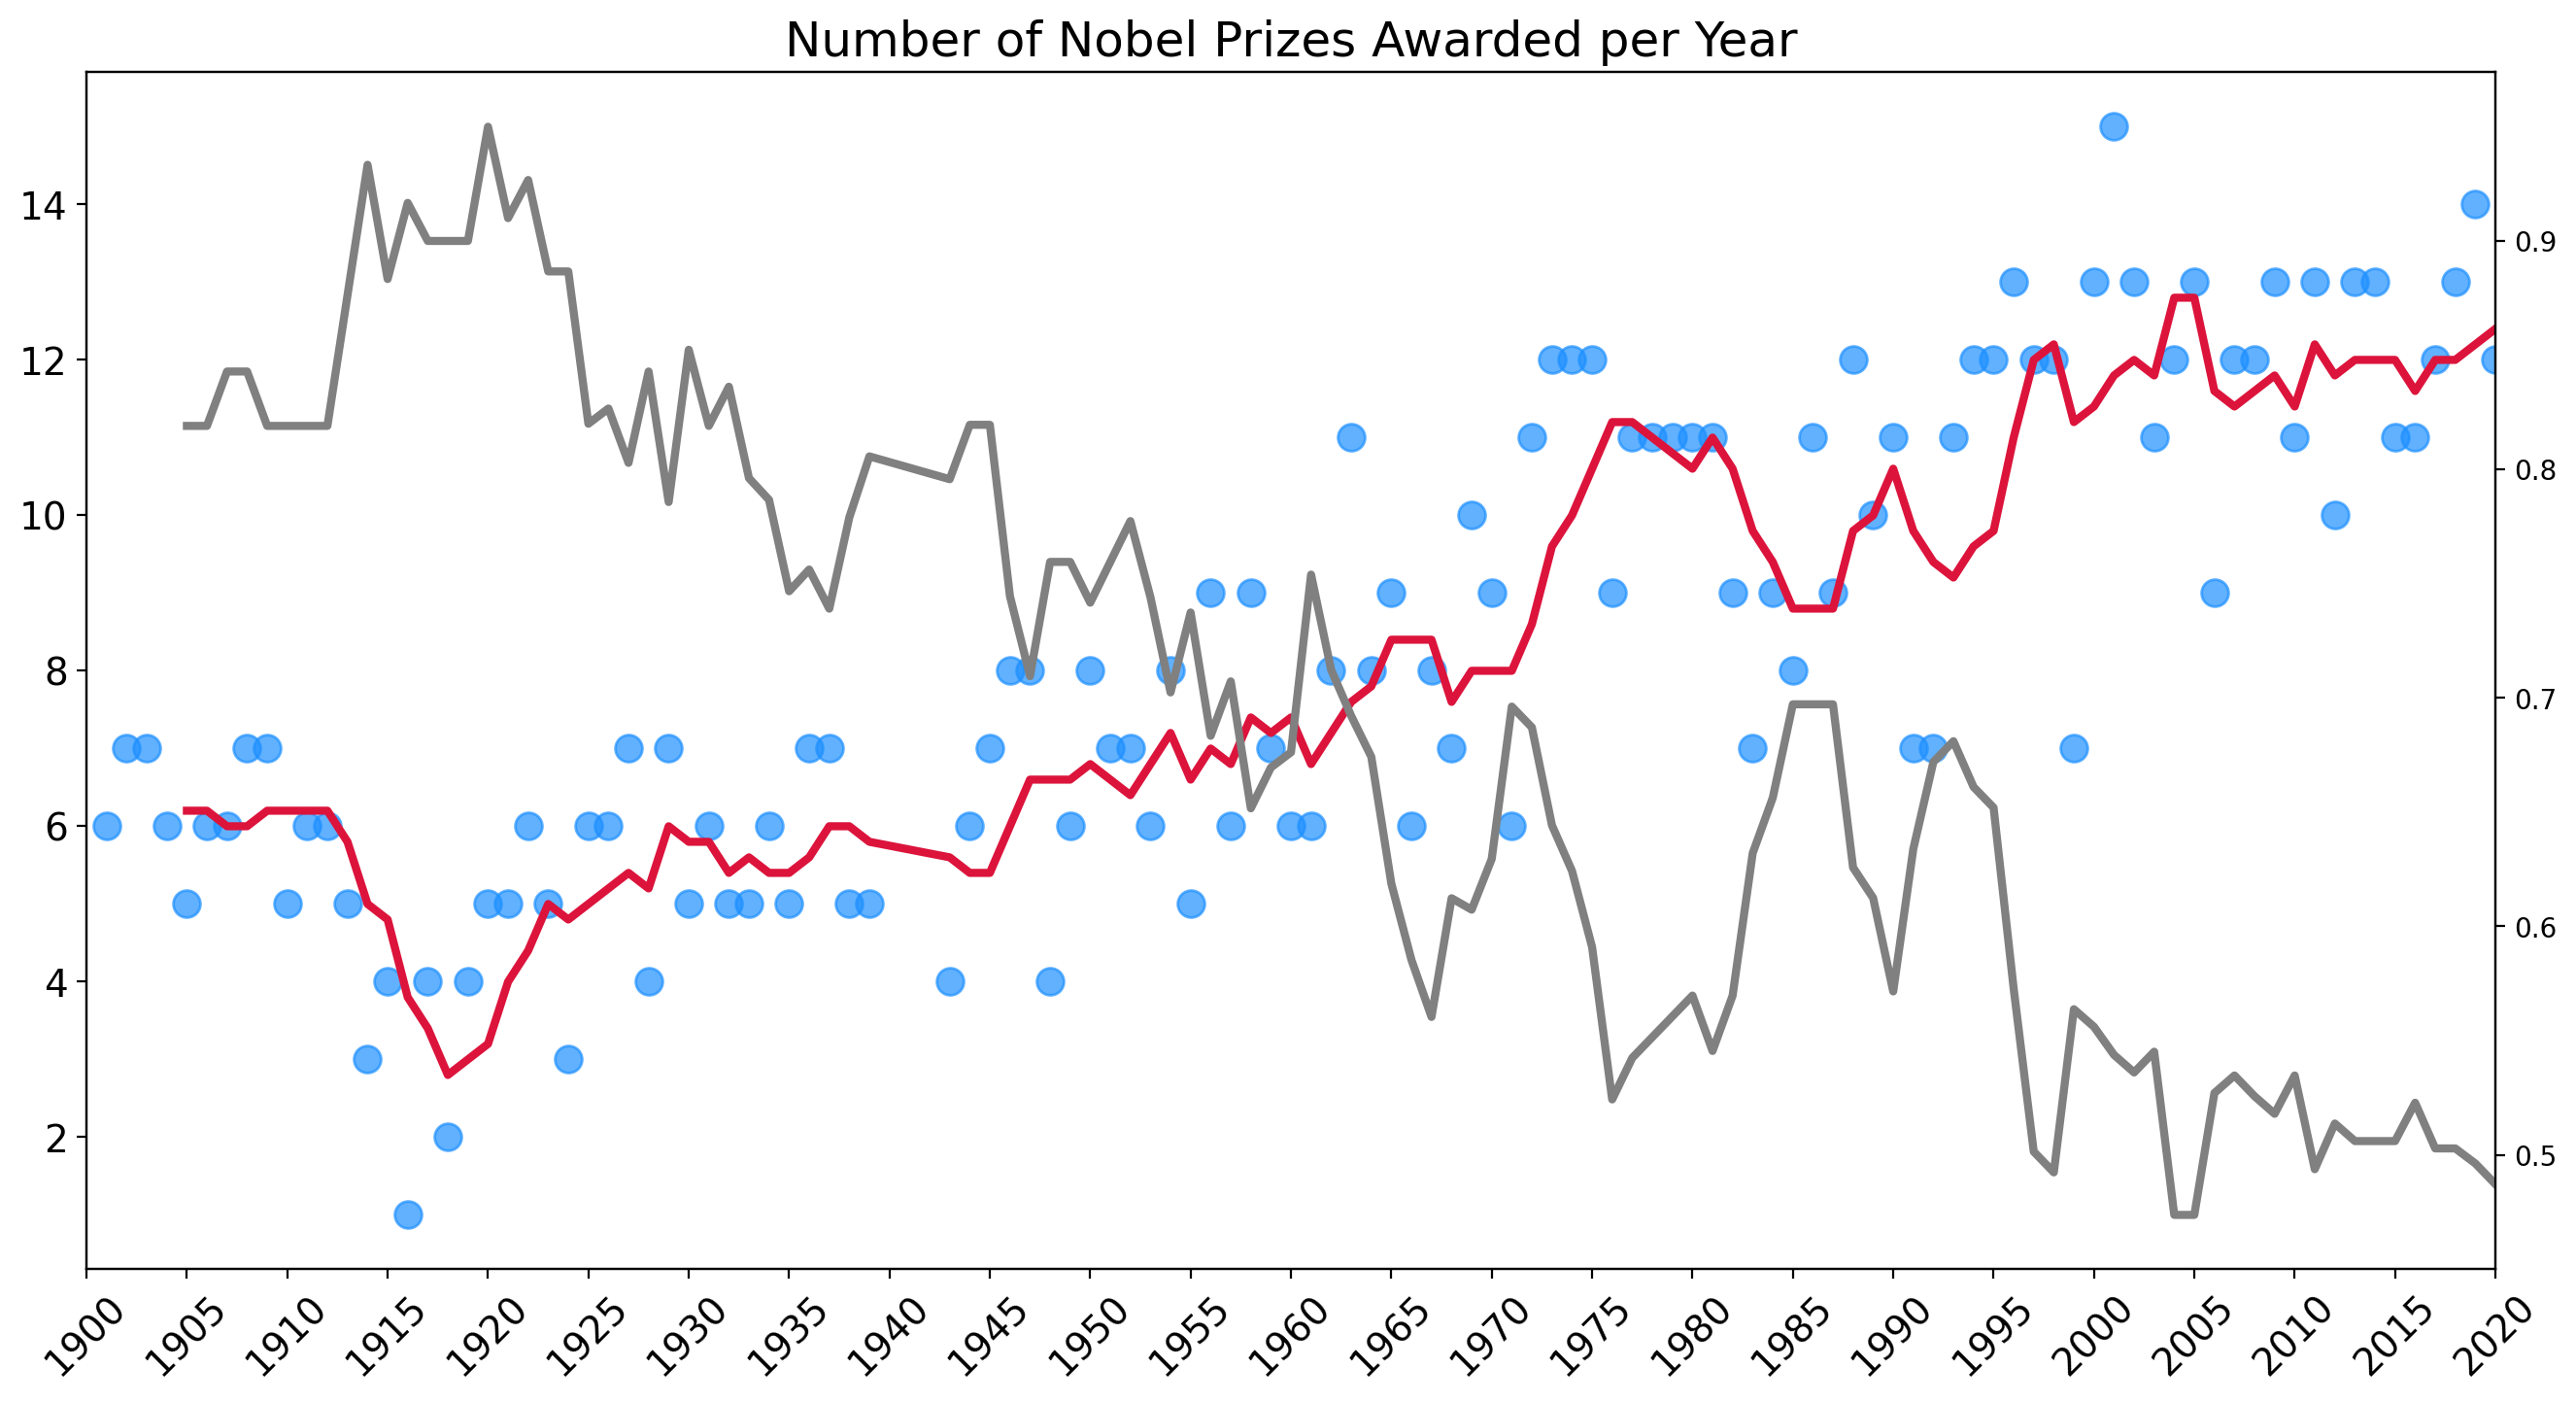

In [ ]:
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx() # create second y-axis
ax1.set_xlim(1900, 2020)

ax1.scatter(x=prizes_per_year.index,
           y=prizes_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

ax1.plot(prizes_per_year.index,
        moving_avg.values,
        c='crimson',
        linewidth=3,)

# Adding prize share plot on second axis
ax2.plot(prizes_per_year.index,
        share_moving_average.values,
        c='grey',
        linewidth=3,)

plt.show()

# The Countries with the Most Nobel Prizes


* Create a Pandas DataFrame called `top20_countries` that has the two columns. The `prize` column should contain the total number of prizes won.

<img src=https://i.imgur.com/6HM8rfB.png width=350>

* Is it best to use `birth_country`, `birth_country_current` or `organization_country`?
* What are some potential problems when using `birth_country` or any of the others? Which column is the least problematic?
* Then use plotly to create a horizontal bar chart showing the number of prizes won by each country. Here's what you're after:

<img src=https://i.imgur.com/agcJdRS.png width=750>

* What is the ranking for the top 20 countries in terms of the number of prizes?

In [ ]:
top20_countries=df_data.groupby('birth_country_current')['prize'].count().sort_values().tail(20).reset_index()

In [ ]:
h_bar = px.bar(x=top20_countries.prize,
               y=top20_countries.birth_country_current,
               orientation='h',
               color_continuous_scale='Viridis',
               color=top20_countries.prize,
               title='Top 20 Countries by Number of Prizes')
h_bar.update_layout(xaxis_title='number of prizes', yaxis_title='Country')
h_bar.show()

In [ ]:
df_countries = df_data.groupby(['birth_country_current', 'ISO'], as_index=False)['prize'].count().sort_values('prize',ascending=False)

# Use a Choropleth Map to Show the Number of Prizes Won by Country

* Create this choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/):

<img src=https://i.imgur.com/s4lqYZH.png>




In [ ]:
world_map = px.choropleth(df_countries,
                          locations='ISO',
                          color='prize',
                          hover_name='birth_country_current',
                          color_continuous_scale=px.colors.sequential.matter)
world_map.update_layout(coloraxis_showscale=True)
world_map.show()

In [ ]:
cat_country=df_data.groupby(['birth_country_current','category'], as_index=False)['prize'].count().sort_values('prize',ascending=False)

In [ ]:
merged_df = pd.merge(cat_country,top20_countries,on='birth_country_current')
merged_df.columns = ['birth_country_current', 'category', 'cat_prize', 'total_prize']
merged_df.sort_values('total_prize', inplace=True)


In [ ]:
cat_country_bar = px.bar(x=merged_df.cat_prize,
                         y=merged_df.birth_country_current,
                         color=merged_df.category,
                         orientation='h',
                         title='Top 20 Countries by Number of Prizes and Category')
cat_country_bar.update_layout(xaxis_title='Number of Prizes', yaxis_title='Country')
cat_country_bar.show()

In [ ]:
prize_by_year = df_data.groupby(by=['birth_country_current', 'year'], as_index=False).count()
prize_by_year = prize_by_year.sort_values('year')[['year', 'birth_country_current', 'prize']]

In [ ]:
cumulative_prizes = prize_by_year.groupby(by=['birth_country_current','year']).sum().groupby(level=[0]).cumsum()
cumulative_prizes.reset_index(inplace=True)

In [ ]:
l_chart = px.line(cumulative_prizes,
                  x='year',
                  y='prize',
                  color='birth_country_current',
                  hover_name='birth_country_current')

l_chart.update_layout(xaxis_title='Year',
                      yaxis_title='Number of Prizes')

l_chart.show()

# In Which Categories are the Different Countries Winning Prizes?

Divide the plotly bar chart to show which categories made up the total number of prizes. Here's what you're aiming for:

<img src=https://i.imgur.com/iGaIKCL.png>

* In which category are Germany and Japan the weakest compared to the United States?
* In which category does Germany have more prizes than the UK?
* In which categories does France have more prizes than Germany?
* Which category makes up most of Australia's nobel prizes?
* Which category makes up half of the prizes in the Netherlands?
* Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?



In [ ]:
top20_orgs=df_data.organization_name.value_counts()[:20]
top20_orgs.sort_values(ascending=True, inplace=True)
print(top20_countries)


       birth_country_current  prize
0                      India      9
1                    Hungary      9
2               South Africa      9
3                  Australia     10
4                    Denmark     12
5                      China     12
6                     Norway     12
7                    Austria     18
8                Netherlands     18
9                      Italy     19
10               Switzerland     19
11                    Canada     20
12                    Russia     26
13                    Poland     27
14                     Japan     27
15                    Sweden     29
16                    France     57
17                   Germany     84
18            United Kingdom    105
19  United States of America    281


### Number of Prizes Won by Each Country Over Time

* When did the United States eclipse every other country in terms of the number of prizes won?
* Which country or countries were leading previously?
* Calculate the cumulative number of prizes won by each country in every year. Again, use the `birth_country_current` of the winner to calculate this.
* Create a [plotly line chart](https://plotly.com/python/line-charts/) where each country is a coloured line.

In [ ]:
org_bar = px.bar(x = top20_orgs.values,
                 y = top20_orgs.index,
                 orientation='h',
                 color=top20_orgs.values,
                #  color_continuous_scale=px.colors.sequential.haline,
                 title='Top 20 Research Institutions by Number of Prizes')
org_bar.update_layout(xaxis_title='Number of Prizes',
                      yaxis_title='Institution',
                      coloraxis_showscale=False)
org_bar.show()

In [ ]:
top20_org_cities = df_data.organization_city.value_counts()[:20]
top20_org_cities.sort_values(ascending=True, inplace=True)

In [ ]:
city_bar2 = px.bar(x = top20_org_cities.values,
                  y = top20_org_cities.index,
                  orientation='h',
                  color=top20_org_cities.values,
                  color_continuous_scale=px.colors.sequential.Plasma,
                  title='Which Cities Do the Most Research?')

city_bar2.update_layout(xaxis_title='Number of Prizes',
                       yaxis_title='City',
                       coloraxis_showscale=False)
city_bar2.show()


In [ ]:
top20_cities = df_data.birth_city.value_counts()[:20]
top20_cities.sort_values(ascending=True, inplace=True)

In [ ]:
city_bar = px.bar(
    x=top20_cities.values,
    y=top20_cities.index,
    title='Where are most of the Nobel Laureates Born?',
    color=top20_cities.values,
)
city_bar.update_layout(xaxis_title='Number of Prizes',yaxis_title='City',coloraxis_showscale=False)
city_bar.show()

# What are the Top Research Organisations?

Create a bar chart showing the organisations affiliated with the Nobel laureates. It should looks something like this:

<img src=https://i.imgur.com/zZihj2p.png width=600>

* Which organisations make up the top 20?
* How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?

# Which Cities Make the Most Discoveries?

Where do major discoveries take place?  

* Create another plotly bar chart graphing the top 20 organisation cities of the research institutions associated with a Nobel laureate.
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

# Where are Nobel Laureates Born? Chart the Laureate Birth Cities

**Challenge**:
* Create a plotly bar chart graphing the top 20 birth cities of Nobel laureates.
* Use a named colour scale called `Plasma` for the chart.
* What percentage of the United States prizes came from Nobel laureates born in New York?
* How many Nobel laureates were born in London, Paris and Vienna?
* Out of the top 5 cities, how many are in the United States?


# Plotly Sunburst Chart: Combine Country, City, and Organisation

* Create a DataFrame that groups the number of prizes by organisation.
* Then use the [plotly documentation to create a sunburst chart](https://plotly.com/python/sunburst-charts/)
* Click around in your chart, what do you notice about Germany and France?


Here's what you're aiming for:

<img src=https://i.imgur.com/cemX4m5.png width=300>



In [ ]:
df_data[:2]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD,1.00
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA,1.00


In [ ]:
country_city_org = df_data.groupby(
    by=['organization_country','organization_city','organization_name'],
    as_index=False,
    ).agg({'prize': pd.Series.count})

In [ ]:
country_city_org=country_city_org.sort_values(ascending=False, by='prize')

In [ ]:
burst = px.sunburst(country_city_org,
                    path=['organization_country','organization_city','organization_name'],
                    values='prize',
                    title='where do Discoveries Take Place?')
burst.update_layout(xaxis_title='Number of Prizes',
                    yaxis_title = 'City',
                    coloraxis_showscale=False)
burst.show()

### Who were the oldest and youngest winners?

* What are the names of the youngest and oldest Nobel laureate?
* What did they win the prize for?
* What is the average age of a winner?
* 75% of laureates are younger than what age when they receive the prize?
* Use Seaborn to [create histogram](https://seaborn.pydata.org/generated/seaborn.histplot.html) to visualise the distribution of laureate age at the time of winning. Experiment with the number of `bins` to see how the visualisation changes.

# Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

Calculate the age of the laureate in the year of the ceremony and add this as a column called `winning_age` to the `df_data` DataFrame. Hint: you can use [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.html) to help you.



In [ ]:
df_data['winning_age'] = df_data.year - df_data.birth_date.dt.year
df_data.sort_values('winning_age',ascending=False)[:1]
df_data.sort_values('winning_age')[:1]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,age,winning_age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Pakistan,Female,NaN,NaN,NaN,PAK,0.50,17.00,17.00


### Descriptive Statistics for the Laureate Age at Time of Award

* Calculate the descriptive statistics for the age at the time of the award.
* Then visualise the distribution in the form of a histogram using [Seaborn's .histplot() function](https://seaborn.pydata.org/generated/seaborn.histplot.html).
* Experiment with the `bin` size. Try 10, 20, 30, and 50.  

In [ ]:
df_data.winning_age.describe()

,winning_age
count,934.00
mean,59.95
std,12.62
min,17.00
25%,51.00
50%,60.00
75%,69.00
max,97.00


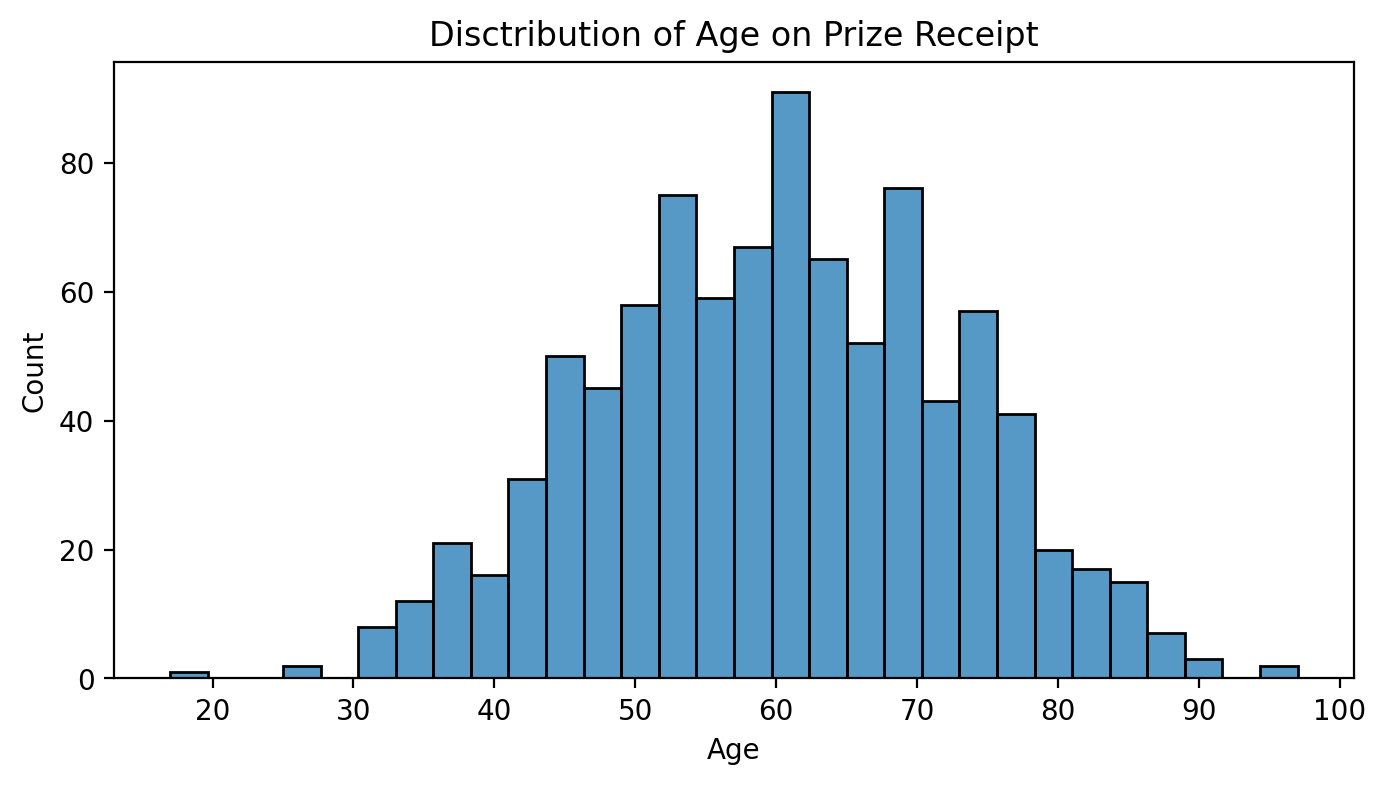

In [ ]:
plt.figure(figsize=(8,4),dpi=200)
sns.histplot(data=df_data,
             x=df_data.winning_age,
             bins=30)
plt.xlabel('Age')
plt.title('Disctribution of Age on Prize Receipt')
plt.show()

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?

* Use Seaborn to [create a .regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html?highlight=regplot#seaborn.regplot) with a trendline.
* Set the `lowess` parameter to `True` to show a moving average of the linear fit.
* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?


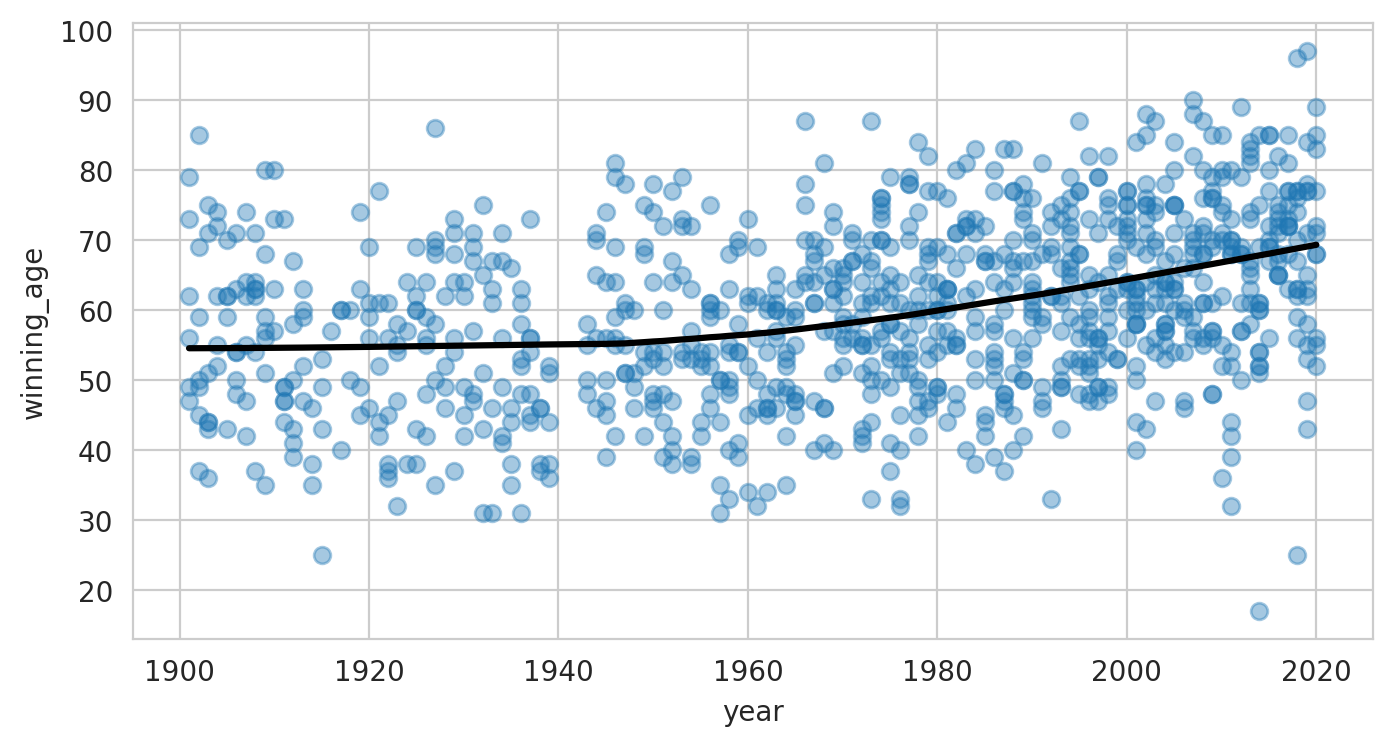

In [ ]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('whitegrid'):
  sns.regplot(data=df_data,
              x='year',
              y='winning_age',
              lowess=True,
              scatter_kws={'alpha':0.4},
              line_kws={'color':'black'})
plt.show()

### Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category?

* Use Seaborn's [`.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot) to show how the mean, quartiles, max, and minimum values vary across categories. Which category has the longest "whiskers"?
* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

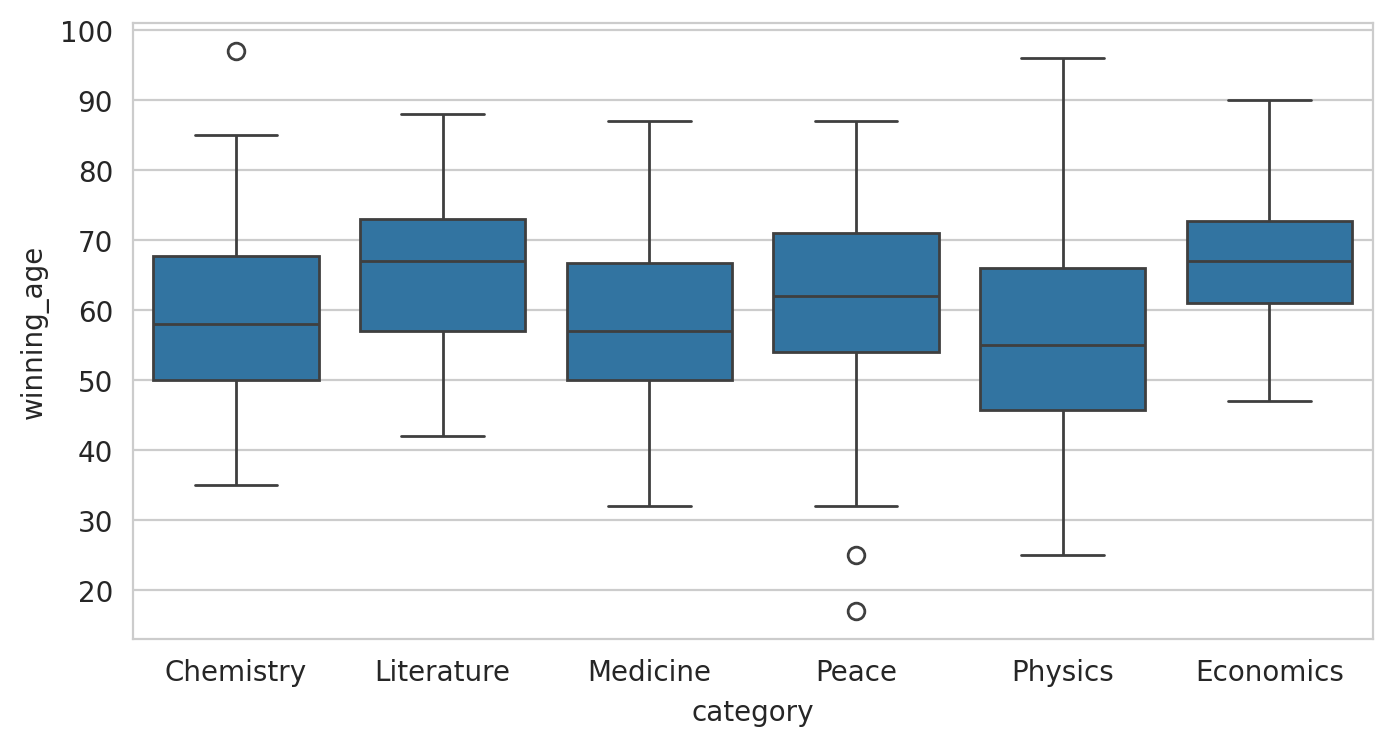

In [ ]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('whitegrid'):
  sns.boxplot(data=df_data,
              x='category',
              y='winning_age')
plt.show()


* Use Seaborn's [`.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot) and the `row` parameter to create 6 separate charts for each prize category. Again set `lowess` to `True`.
* What are the winning age trends in each category?
* Which category has the age trending up and which category has the age trending down?
* Is this `.lmplot()` telling a different story from the `.boxplot()`?
* Create another chart with Seaborn. This time use `.lmplot()` to put all 6 categories on the same chart using the `hue` parameter.


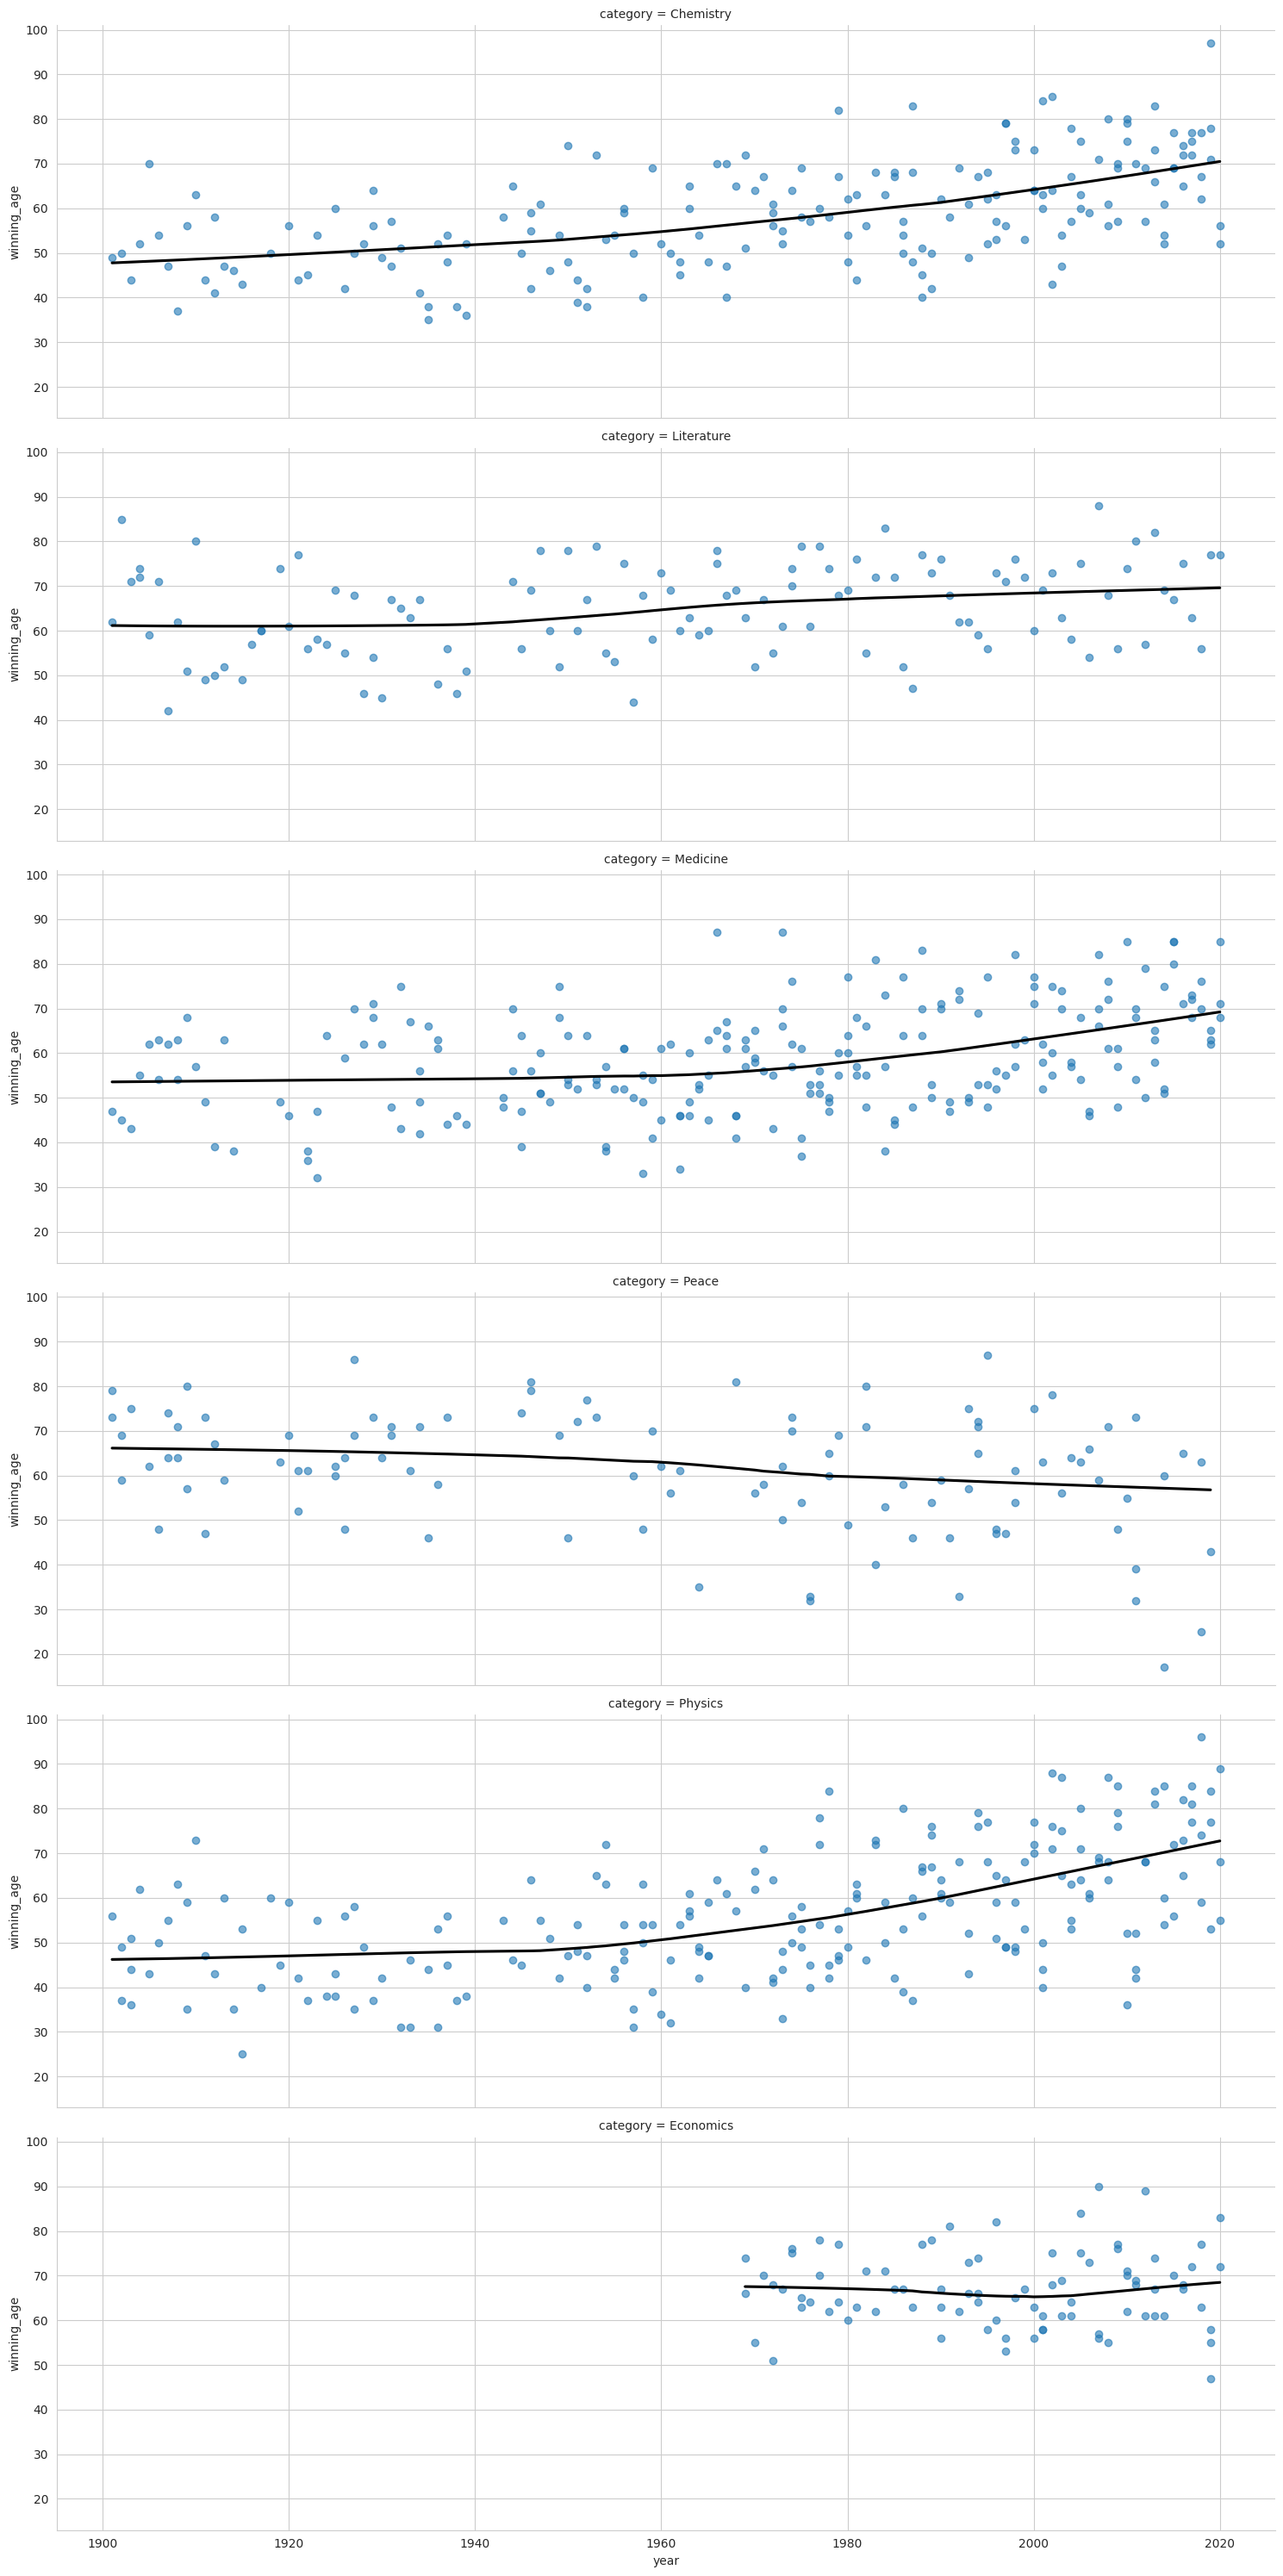

In [ ]:
with sns.axes_style('whitegrid'):
  sns.lmplot(data=df_data,
             x='year',
             y='winning_age',
             row='category',
             lowess=True,
             aspect=3,
             scatter_kws={'alpha':0.6},
             line_kws={'color':'black'})
plt.show()

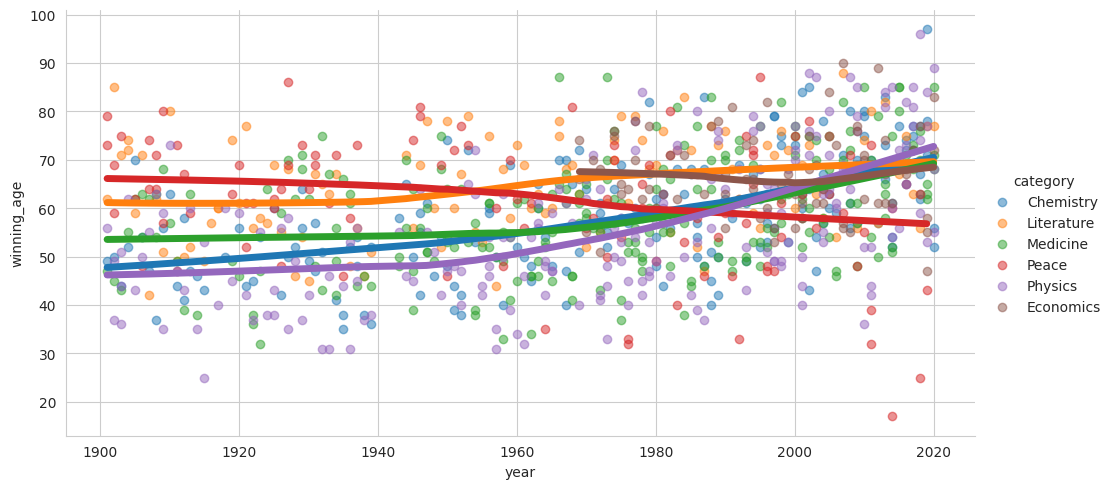

In [ ]:
with sns.axes_style('whitegrid'):
  sns.lmplot(data=df_data,
             x='year',
             y='winning_age',
             hue='category',
             lowess=True,
             aspect=2,
             scatter_kws={'alpha':0.5},
             line_kws={'linewidth':5})
plt.show()